# WORK 3 : Glitch Analysis using Vanilla and Joint GARCH

This notebook compares standard Gaussian parameter estimation with Joint GARCH parameter estimation when a gravitational-wave signal is contaminated by transient glitches. Three glitch locations are considered (beginning, middle, and end of the chirp) to study how the glitch position affects parameter recovery.

## Workflow

1. Generate white Gaussian noise.
2. Generate a toy inspiral chirp with the chosen chirp rate and coalescence time.
3. Scale the waveform to the required signal-to-noise ratio (SNR).
4. Inject a sine-Gaussian glitch at three different locations:
   - Beginning of the chirp
   - Middle of the chirp
   - End of the chirp
5. For each glitch case:
   - Combine signal, noise, and glitch.
   - Select the analysis window around the signal.
6. Estimate the signal parameters using the Vanilla Gaussian likelihood:
   - Sample `(cr, tc)` using MCMC.
   - Generate posterior distributions and corner plots.
7. Estimate the signal parameters using the Joint GARCH likelihood:
   - Sample `(cr, tc, ω, α, β)` simultaneously.
   - Perform GARCH variance recursion at every MCMC step.
   - Generate posterior distributions and corner plots.
8. Compare the estimated parameters from both methods for each glitch position.

## Outputs

- Signal, glitch, and data plots
- Vanilla MCMC corner plots
- Joint GARCH corner plots
- Estimated values of `cr` and `tc`
- Estimated GARCH parameters `(ω, α, β)`
- Comparison of Vanilla and Joint GARCH results

Noise standard deviation = 1.003e-22
Signal amplitude = 5.162e-24
Injected SNR     = 10.00


Running Case : End


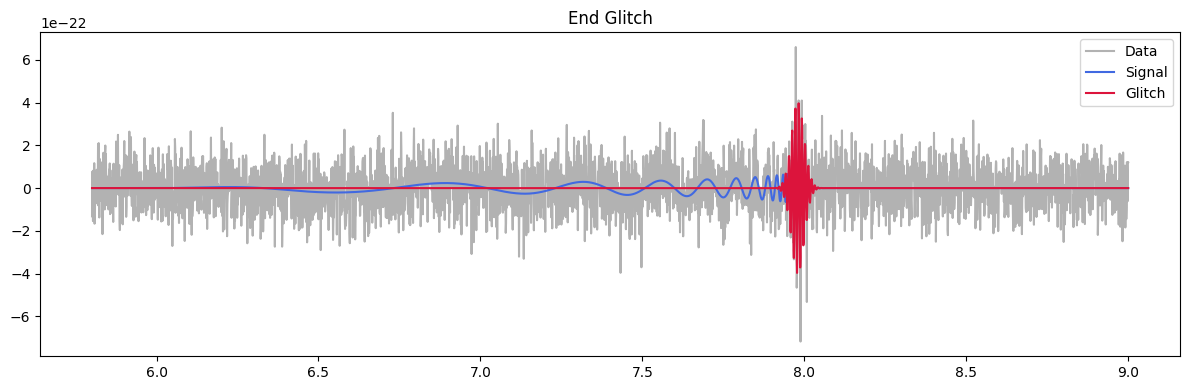

Running Vanilla MCMC...


100%|██████████████████████████████████████| 5000/5000 [00:34<00:00, 144.73it/s]


Finished.
(4256, 2)


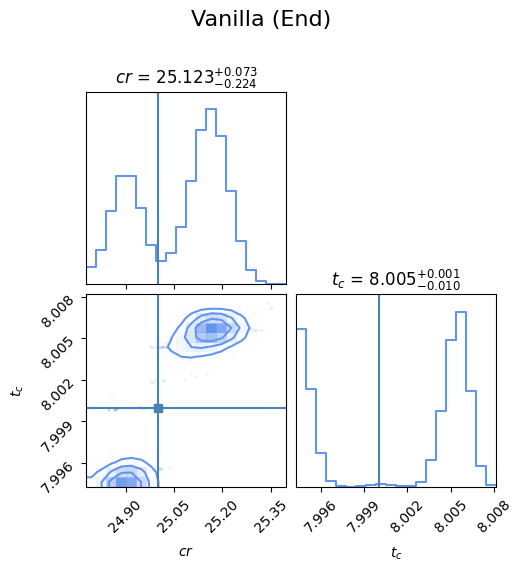

Running Joint GARCH MCMC...


100%|███████████████████████████████████████| 5000/5000 [24:50<00:00,  3.36it/s]


Finished.
(12000, 5)


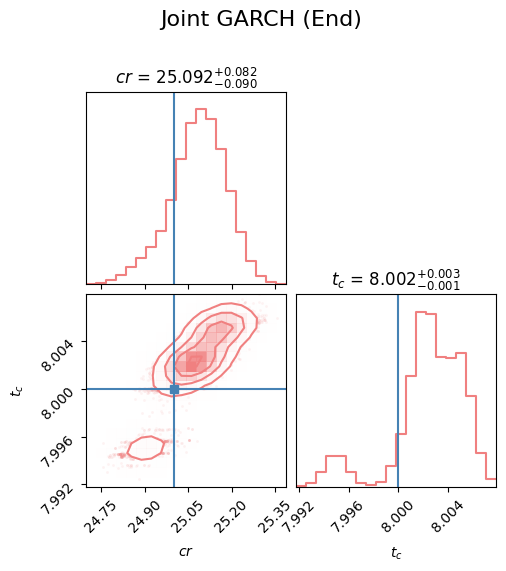

omega = 0.0006648435237595109
alpha = 0.034999787979639166
beta  = 0.9051242889021998


Results : End
Vanilla :
cr = 25.067 ± 0.132
tc = 8.0016 ± 0.0049

Joint GARCH :
cr = 25.085 ± 0.091
tc = 8.0025 ± 0.0028


Running Case : Middle


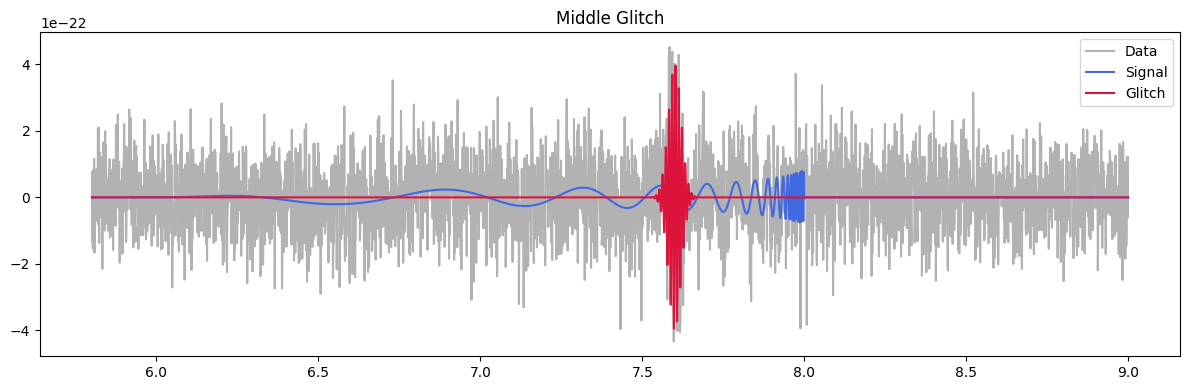

Running Vanilla MCMC...


100%|██████████████████████████████████████| 5000/5000 [00:34<00:00, 143.64it/s]


Finished.
(4256, 2)


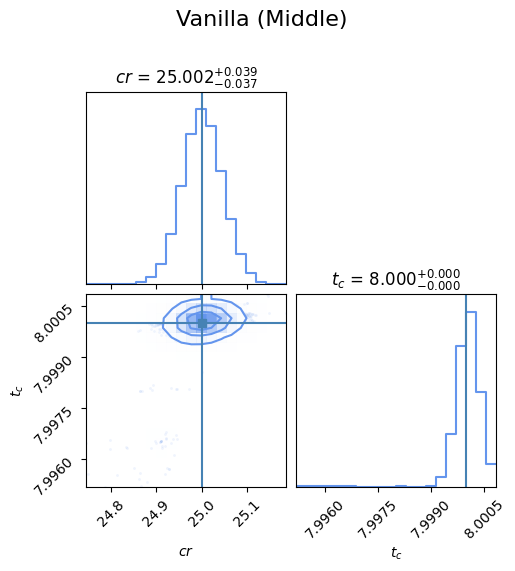

Running Joint GARCH MCMC...


100%|███████████████████████████████████████| 5000/5000 [24:40<00:00,  3.38it/s]


Finished.
(12000, 5)


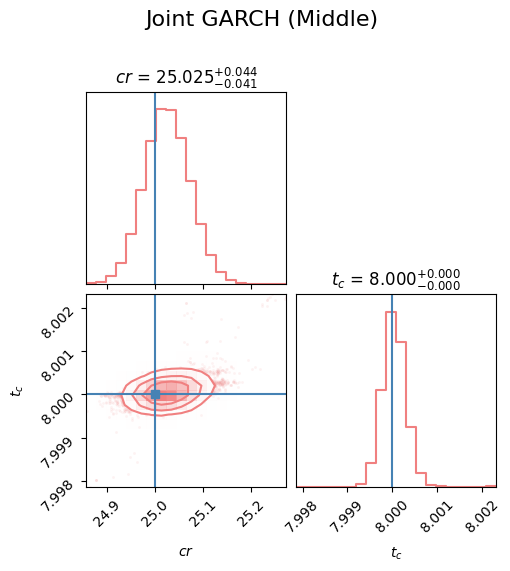

omega = 0.0009958918051813322
alpha = 0.04361779870155083
beta  = 0.8673740603598445


Results : Middle
Vanilla :
cr = 25.002 ± 0.040
tc = 8.0000 ± 0.0004

Joint GARCH :
cr = 25.027 ± 0.044
tc = 8.0001 ± 0.0002


Running Case : Beginning


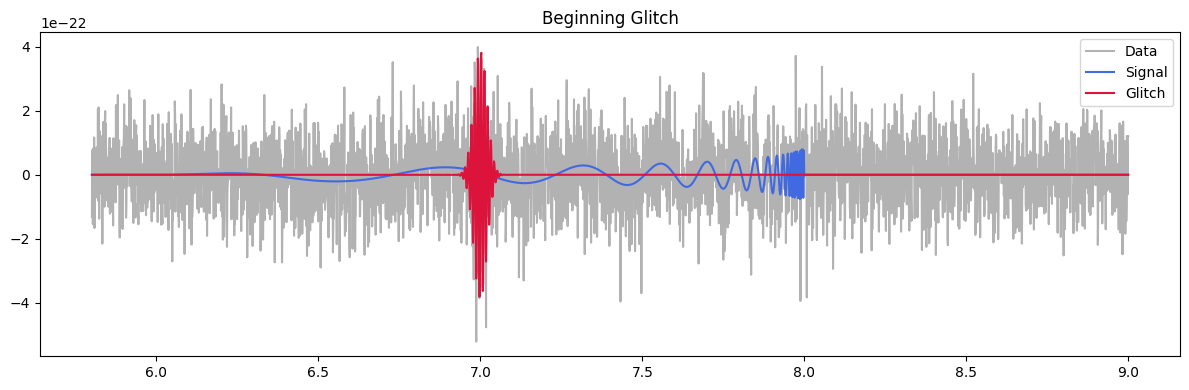

Running Vanilla MCMC...


100%|██████████████████████████████████████| 5000/5000 [00:34<00:00, 146.76it/s]


Finished.
(4256, 2)


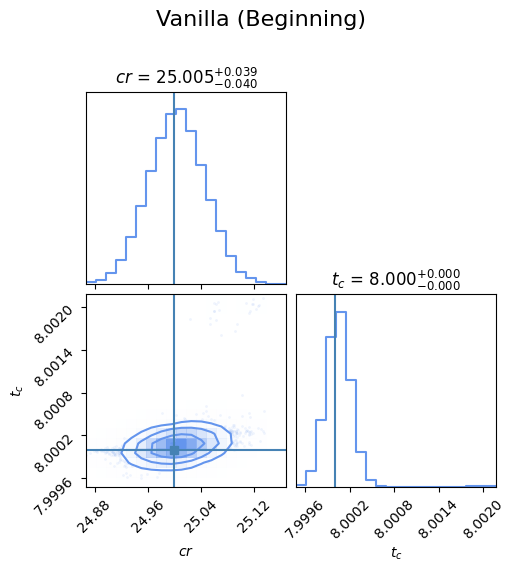

Running Joint GARCH MCMC...


100%|███████████████████████████████████████| 5000/5000 [24:38<00:00,  3.38it/s]


Finished.
(12000, 5)


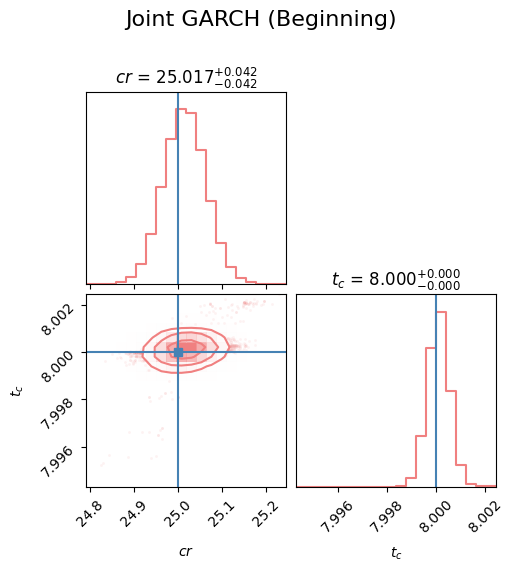

omega = 0.000549165389391196
alpha = 0.030301700841004996
beta  = 0.9201268962455391


Results : Beginning
Vanilla :
cr = 25.004 ± 0.040
tc = 8.0001 ± 0.0002

Joint GARCH :
cr = 25.017 ± 0.043
tc = 8.0001 ± 0.0003


In [20]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal.windows import tukey
from numba import njit
import emcee
import corner
from arch import arch_model

# =====================================================
# Simulation Parameters
# =====================================================

np.random.seed(42)
fs = 1024                     # Sampling frequency (Hz)
duration = 10.0               # Duration (s)

t = np.arange(0, duration, 1/fs)
N = len(t)

sigma_noise = 1e-22           # Detector noise

# =====================================================
# True Signal Parameters
# =====================================================

cr_true = 25.0
tc_true = 8.0

target_snr = 10

# =====================================================
# Generate White Gaussian Noise
# =====================================================

noise = np.random.normal(0,sigma_noise,N)
print(f"Noise standard deviation = {np.std(noise):.3e}")

# =====================================================
# Toy Chirp Model (Numba Compatible)
# =====================================================

def generate_chirp(t, A, chirp_rate, t_c):
    h = np.zeros_like(t)

    valid = (t < t_c) & (t > (t_c - 2.0))

    if not np.any(valid):
        return h

    tau = t_c - t[valid]

    phase = -2.0 * chirp_rate * (tau + 1e-5)**(-0.25)

    amplitude = A * np.sqrt(chirp_rate / (tau + 0.1))

    signal = amplitude * np.sin(phase)

    # Tukey window only at the beginning
    window = tukey(len(signal), alpha=0.5)
    taper = np.ones_like(signal)
    half = len(window) // 2
    taper[:half] = window[:half]
    signal *= taper

    h[valid] = signal

    return h

# =====================================================
# Scale the Chirp to the Desired SNR
# =====================================================

signal_unit = generate_chirp(t, 1.0, cr_true, tc_true)

snr_unit = np.sqrt(np.sum(signal_unit**2)) / sigma_noise

A_true = target_snr / snr_unit

h_true = generate_chirp(t, A_true, cr_true, tc_true)

snr = np.sqrt(np.sum(h_true**2)) / sigma_noise

print(f"Signal amplitude = {A_true:.3e}")
print(f"Injected SNR     = {snr:.2f}")

# =====================================================
# Analysis Window
# =====================================================

t_start = tc_true - 2.2
t_end = tc_true + 1.0

# =====================================================
# Section 6: Generate a Sine-Gaussian Glitch
# =====================================================


glitch_cases = {
    "End": 7.98,
    "Middle": 7.60,
    "Beginning": 7.00
}

# Glitch parameters
glitch_amp = 4e-22        # Amplitude
glitch_tau = 0.020        # Gaussian width (s)
glitch_f0 = 100           # Central frequency (Hz)

for case_name, glitch_t0 in glitch_cases.items():

    print("\n")
    print("="*70)
    print(f"Running Case : {case_name}")
    print("="*70)

    # --------------------------------------------------
    # Generate glitch
    # --------------------------------------------------

    glitch = (
        glitch_amp
        * np.exp(-((t-glitch_t0)**2)/(2*glitch_tau**2))
        * np.sin(2*np.pi*glitch_f0*(t-glitch_t0))
    )

    data = noise + h_true + glitch

    # --------------------------------------------------
    # Analysis window
    # --------------------------------------------------

    mask = (t >= t_start) & (t <= t_end)

    t_analysis = t[mask]
    data_analysis = data[mask]
    signal_analysis = h_true[mask]
    glitch_analysis = glitch[mask]

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------

    plt.figure(figsize=(12,4))

    plt.plot(t_analysis,data_analysis,
             color="gray",alpha=0.6,label="Data")

    plt.plot(t_analysis,signal_analysis,
             color="royalblue",label="Signal")

    plt.plot(t_analysis,glitch_analysis,
             color="crimson",label="Glitch")

    plt.title(f"{case_name} Glitch")

    plt.legend()

    plt.tight_layout()

    plt.show()


    from numba import njit
    import numpy as np

# =====================================================
# Vanilla Gaussian Log-Likelihood
# =====================================================

    def vanilla_log_likelihood(cr, tc, t, data, sigma, A):
        model = generate_chirp(t, A, cr, tc)
        residual = data - model
        N = len(data)
        logL = (-0.5 * N * np.log(2.0 * np.pi * sigma**2)-0.5 * np.sum(residual**2) / sigma**2)
        return logL

# =====================================================
# Prior Distribution
# =====================================================

    def log_prior(theta):
        cr, tc = theta
        if 23.0 < cr < 27.0 and 7.8 < tc < 8.2:
            return 0.0
        return -np.inf

# =====================================================
# Posterior Probability
# =====================================================

    def log_probability(theta):
        lp = log_prior(theta)
        if not np.isfinite(lp):
            return -np.inf
        cr, tc = theta
        return lp + vanilla_log_likelihood(cr,tc,t_analysis,data_analysis,sigma_noise,A_true)

# =====================================================
# Initialize MCMC
# =====================================================

    ndim = 2
    nwalkers = 32

    initial = np.array([cr_true, tc_true])
    pos = initial + np.array([0.01 * np.random.randn(nwalkers),0.0005 * np.random.randn(nwalkers)]).T

# =====================================================
# Run Vanilla MCMC
# =====================================================

    sampler = emcee.EnsembleSampler(nwalkers,ndim,log_probability)
    print("Running Vanilla MCMC...")

    sampler.run_mcmc(pos,5000,progress=True)
    print("Finished.")

# =====================================================
# Extract Posterior Samples
# =====================================================

    samples = sampler.get_chain(discard=1000,thin=30,flat=True)
    print(samples.shape)

# =====================================================
# Vanilla Corner Plot
# =====================================================

    figure = corner.corner(samples,labels=[r"$cr$", r"$t_c$"],truths=[cr_true, tc_true],smooth=1.0,smooth1d=1.0,show_titles=True,
        color="cornflowerblue",title_fmt=".3f")
    figure.suptitle(f"Vanilla ({case_name})", fontsize=16, y=1.05)
    figure.subplots_adjust(top=0.90)
    plt.show()
    plt.close()

# =====================================================
# Parameter Estimates : Vanilla
# =====================================================

    cr_est = np.mean(samples[:,0])
    tc_est = np.mean(samples[:,1])

    cr_std = np.std(samples[:,0])
    tc_std = np.std(samples[:,1])

    # Save vanilla results
    cr_est_vanilla = cr_est
    tc_est_vanilla = tc_est

    cr_std_vanilla = cr_std
    tc_std_vanilla = tc_std

#---------------------------------------------------------------------------------------------------
#=============================================GARCH=================================================
#---------------------------------------------------------------------------------------------------



# =====================================================
# GARCH(1,1) Variance Recursion
# =====================================================

    def garch_sigma(residual, omega, alpha, beta):
        N = len(residual)
        sigma2 = np.empty(N)
        sigma2[0] = omega / (1.0 - alpha - beta)
        for i in range(1, N):
            sigma2[i] = (omega+ alpha * residual[i-1]**2+ beta * sigma2[i-1])
        return np.sqrt(sigma2)

# =====================================================
# Fixed GARCH Log-Likelihood
# =====================================================

    def garch_log_likelihood(cr, tc, t, data,omega, alpha, beta,A):
        model = generate_chirp(t, A, cr, tc)
        residual = data - model
        scale = 1e21
        residual_scaled = residual * scale
        sigma = garch_sigma(residual_scaled,omega,alpha,beta)
        logL = 0.0
        for i in range(len(data)):
            logL += (-0.5*np.log(2*np.pi*sigma[i]**2)-0.5*residual_scaled[i]**2/sigma[i]**2)
        return logL

# =====================================================
# Prior
# =====================================================

    def garch_log_prior(theta):

        cr, tc, omega, alpha, beta = theta

        if (
            23 < cr < 27
            and 7.8 < tc < 8.2
            and omega > 0
            and 0 < alpha < 1
            and 0 < beta < 1
            and alpha + beta < 1
        ):
            return 0.0

        return -np.inf

# =====================================================
# Posterior
# =====================================================

    def garch_log_probability(theta):

        lp = garch_log_prior(theta)

        if not np.isfinite(lp):
            return -np.inf

        cr, tc, omega, alpha, beta = theta

        return lp + garch_log_likelihood(
            cr,
            tc,
            t_analysis,
            data_analysis,
            omega,
            alpha,
            beta,
            A_true
        )
# =====================================================
# Initialize GARCH MCMC
# =====================================================

    ndim = 5
    nwalkers = 40

    initial = np.array([
        cr_true,
        tc_true,
        0.05,     # omega
        0.10,     # alpha
        0.80      # beta
    ])
    pos = initial + np.array([
        0.01*np.random.randn(nwalkers),      # cr
        0.0005*np.random.randn(nwalkers),    # tc
        0.005*np.random.randn(nwalkers),     # omega
        0.01*np.random.randn(nwalkers),      # alpha
        0.01*np.random.randn(nwalkers),      # beta
    ]).T
    
# =====================================================
# Run GARCH MCMC
# =====================================================

    sampler_garch = emcee.EnsembleSampler(nwalkers,ndim,garch_log_probability)
    print("Running Joint GARCH MCMC...")

    sampler_garch.run_mcmc(pos,5000,progress=True)
    print("Finished.")

# =====================================================
# Extract Posterior Samples
# =====================================================

    samples_garch = sampler_garch.get_chain(discard=2000,thin=10,flat=True)
    print(samples_garch.shape)

# =====================================================
# Joint GARCH Corner Plot
# =====================================================

    figure = corner.corner(
        samples_garch[:, :2],          # Only cr and tc
        labels=[r"$cr$", r"$t_c$"],
        truths=[cr_true, tc_true],
        show_titles=True,
        color="lightcoral",
        title_fmt=".3f",
        smooth=1.0,
        smooth1d=1.0,
        title_kwargs={"fontsize":12}
    )
    figure.suptitle(f"Joint GARCH ({case_name})", fontsize=16, y=1.05)
    figure.subplots_adjust(top=0.90)
    plt.show()
    plt.close()

# =====================================================
# GARCH Parameter Estimates
# =====================================================

    cr_est = np.mean(samples_garch[:,0])
    tc_est = np.mean(samples_garch[:,1])

    cr_std = np.std(samples_garch[:,0])
    tc_std = np.std(samples_garch[:,1])

    # Save GARCH results
    cr_est_garch = cr_est
    tc_est_garch = tc_est

    cr_std_garch = cr_std
    tc_std_garch = tc_std

    omega_est = np.mean(samples_garch[:,2])
    alpha_est = np.mean(samples_garch[:,3])
    beta_est  = np.mean(samples_garch[:,4])

    print(f"omega = {omega_est}")
    print(f"alpha = {alpha_est}")
    print(f"beta  = {beta_est}")

# =====================================================
# Comparison
# =====================================================

    print("\n")
    print(f"Results : {case_name}")

    print(f"Vanilla :")
    print(f"cr = {cr_est_vanilla:.3f} ± {cr_std_vanilla:.3f}")
    print(f"tc = {tc_est_vanilla:.4f} ± {tc_std_vanilla:.4f}")

    print()

    print(f"Joint GARCH :")
    print(f"cr = {cr_est_garch:.3f} ± {cr_std_garch:.3f}")
    print(f"tc = {tc_est_garch:.4f} ± {tc_std_garch:.4f}")
    